In [1]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import mido
import numpy as np
import pandas as pd
import partitura as pt
import soundfile as sf
from midi2audio import FluidSynth
from partitura.musicanalysis.performance_codec import get_time_maps_from_alignment
from tqdm import tqdm
from utils import convert_score_to_audio, initialize_config
from madmom.audio.chroma import DeepChromaProcessor

In [ ]:
maestro_path = Path("/Users/jiyun/dataset/MAESTROv2/maestro-v2.0.0")
asap_path = Path("/Users/jiyun/workspace/asap-dataset")
metadata_asap = Path("../data/metadata-asap-test.csv")
batik_path = Path("/Users/jiyun/dataset/Batik_Audio")
vienna_path = Path("/Users/jiyun/workspace/vienna4x22")
metadata_vienna = Path("../data/metadata-vienna.csv")
SOUND_FONT_PATH = "~/.fluidsynth/MuseScore_General.sf2"
conf = initialize_config()

In [ ]:
import numpy as np
import pretty_midi


def compute_chromagram_from_midi(midi_file, fs):
    """
    Compute chromagram from a MIDI file

    Args:
        midi_file (str): Path to the MIDI file
        fs (scalar): Frame rate

    Returns:
        chroma (np.ndarray): Chromagram
        times (np.ndarray): Time array
    """
    # Load MIDI file
    midi_data = pretty_midi.PrettyMIDI(midi_file)

    # Compute chromagram
    chroma = midi_data.get_chroma(fs=fs)

    # Compute time array
    times = np.linspace(0, len(chroma[0]) / fs, num=len(chroma[0]))

    return chroma, times

chroma, times = compute_chromagram_from_midi("../resources/ex_midi_score.mid", 30)
print(chroma.shape, times.shape)

In [ ]:
import matplotlib.pyplot as plt

# Plot the chromagram
plt.figure(figsize=(20, 4))
plt.imshow(chroma, aspect="auto", origin="lower", cmap="viridis")
plt.colorbar()

# Set the x-ticks to be in seconds
xticks = plt.xticks()[0]
plt.xticks(xticks, [str(int(xtick / 30)) for xtick in xticks])

# Set the y-ticks to be note names
plt.yticks(range(12), ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"])

# Add labels to the x-axis and y-axis
plt.xlabel("Time (s)")
plt.ylabel("Note")

plt.show()

In [ ]:
def round_half(num):
    return round(num * 2) / 2


sr = 44100
perf_name = "kv332_1-step-freq0.0625-min_tempo_30-max_tempo_200"
match_file = f"/Users/jiyun/dataset/synthetic_performances_match_midi/match/{perf_name}.match"


perf, alignment, score_obj = pt.load_match(
    filename=match_file,
    create_score=True,
)
perf_midi_path = "./perf_midi.mid"
score_midi_path = "./score_midi.mid"
pt.save_performance_midi(perf, perf_midi_path)
pt.save_score_midi(score_obj, score_midi_path)

# get score audio
# 1. convert score to audio naively
score_audio_path = "./score_audio.wav"
fs = FluidSynth(SOUND_FONT_PATH, sample_rate=sr)
fs.midi_to_audio(score_midi_path, score_audio_path)
y, sr = librosa.load(score_audio_path, sr=sr)
y_trimmed, _ = librosa.effects.trim(y, top_db=30)
sf.write(score_audio_path, y_trimmed, sr)

# 2. get ratio of score and performance
perf_audio_path = f"/Users/jiyun/dataset/synthetic_performances_match_midi/performance_audio/{perf_name}.wav"
score_audio_length = librosa.get_duration(path=score_audio_path)
perf_audio_length = librosa.get_duration(path=perf_audio_path)
ratio = round_half(perf_audio_length / score_audio_length)

has_set_tempo = False
mid = mido.MidiFile(score_midi_path)
for track in mid.tracks:
    for msg in track:
        if msg.type == "set_tempo":
            has_set_tempo = True
            print(f"Original tempo: {mido.tempo2bpm(msg.tempo)}, {msg.tempo}")
            new_tempo = mido.bpm2tempo(mido.tempo2bpm(msg.tempo) / ratio)
            print(f"New tempo: {mido.tempo2bpm(new_tempo)}, {new_tempo}")
            msg.tempo = int(new_tempo)
if not has_set_tempo:
    # If the track does not have a 'set_tempo' message, add one with the default BPM
    default_bpm = 120
    print(f"[Default] Original tempo: {default_bpm}, 500000")
    new_tempo = mido.bpm2tempo(default_bpm / ratio)
    print(f"New tempo: {new_tempo}")
    for track in mid.tracks:
        track.insert(0, mido.MetaMessage("set_tempo", tempo=int(new_tempo)))

mid.save(score_midi_path)

# 3. convert midi to audio (again)
fs = FluidSynth(SOUND_FONT_PATH, sample_rate=sr)
fs.midi_to_audio(score_midi_path, score_audio_path)
y, sr = librosa.load(score_audio_path, sr=sr)
y_trimmed, _ = librosa.effects.trim(y, top_db=30)
sf.write(score_audio_path, y_trimmed, sr)

# Get annotations for perf & score
tick = mid.ticks_per_beat

# Get a structured numpy array of notes in the
# score and notes in the performance
pnote_array = perf.note_array()
snote_array = score_obj.note_array()

# Get interp1d object that map time in the performance
# in seconds to time in the score in beats and the
# other way around
ptime_to_stime_map, stime_to_ptime_map = get_time_maps_from_alignment(
    ppart_or_note_array=pnote_array,
    spart_or_note_array=snote_array,
    alignment=alignment,
)

# To get, e.g., the times of the beats in the
# performance
start_beat = np.ceil(snote_array["onset_beat"].min())
end_beat = np.floor(snote_array["onset_beat"].max())

# beats in the score
beats = np.arange(start_beat, end_beat + 1)
beat_timestamp = np.array(
    [
        score_obj.parts[0].inv_beat_map(beat) / (tick * 2) * ratio # 2 is for 120 bpm
        for beat in beats
    ]
)
np.savetxt(
    f"./score_annotations.tsv", beat_timestamp, delimiter="\t", fmt="%.6f" 
)
performed_beat_times = stime_to_ptime_map(beats)
perf_annots_path = f"./perf_annotations.tsv"
np.savetxt(perf_annots_path, performed_beat_times, delimiter="\t", fmt="%.6f")

# 4. mix score and annotation
df = pd.read_csv("./score_annotations.tsv", delimiter="\t", header=None)
data1, sr = librosa.load(str(score_audio_path), sr=sr)
data2 = librosa.clicks(times=df[0], sr=sr, click_freq=1000, length=len(data1))

mixed = data1 + data2
mixed = mixed / np.max(np.abs(mixed))

mix_audio_path = f"./score_audio_mix.wav"
sf.write(mix_audio_path, mixed, sr)

df = pd.read_csv("./score_annotations.tsv", delimiter="\t", header=None)

# 5. mix performance with annotations
df = pd.read_csv(perf_annots_path, delimiter="\t", header=None)
data1, sr = librosa.load(str(perf_audio_path), sr=sr)
data2 = librosa.clicks(times=df[0], sr=sr, click_freq=1000, length=len(data1))

mixed = data1 + data2
mixed = mixed / np.max(np.abs(mixed))

mix_audio_path = f"./perf_audio_mix.wav"
sf.write(mix_audio_path, mixed, sr)

In [ ]:
# trim audio
metadata_vienna_df = pd.read_csv(metadata_vienna)
for audio_path in metadata_vienna_df["audio_performance"]:
    audio_full_path = vienna_path / audio_path
    y, sr = librosa.load(audio_full_path.as_posix(), sr=sr)
    y_trimmed, _ = librosa.effects.trim(y, top_db=30)
    new_audio_path = vienna_path / "performance_audio" / audio_full_path.name
    sf.write(new_audio_path.as_posix(), y_trimmed, sr)

In [ ]:
# Change / Add audio_score column in the asap metadata
metadata_vienna_df = pd.read_csv(metadata_vienna)
metadata_vienna_df["match"] = metadata_vienna_df["match"].str.replace(".mid", ".match")
metadata_vienna_df.to_csv(metadata_vienna, index=False)

In [ ]:
def round_half(num):
    return round(num * 2) / 2


sr = 44100
metadata_vienna_df = pd.read_csv(metadata_vienna)
for piece_row in metadata_vienna_df.itertuples():
    match_file = str(vienna_path / piece_row.match)
    print(f"Preprocessing {match_file}...")

    perf, alignment, score_obj = pt.load_match(
        filename=match_file,
        create_score=True,
    )
    # perf_midi_path = "./perf_midi.mid"
    score_midi_path = str(vienna_path / piece_row.midi_score)
    pt.save_score_midi(score_obj, score_midi_path)

    # get score audio
    # 1. convert score to audio naively
    score_audio_path = str(vienna_path / piece_row.audio_score)
    fs = FluidSynth(SOUND_FONT_PATH, sample_rate=sr)
    fs.midi_to_audio(score_midi_path, score_audio_path)
    y, sr = librosa.load(score_audio_path, sr=sr)
    y_trimmed, _ = librosa.effects.trim(y, top_db=30)
    sf.write(score_audio_path, y_trimmed, sr)

    # 2. get ratio of score and performance
    perf_audio_path = str(vienna_path / piece_row.audio_performance)
    score_audio_length = librosa.get_duration(path=score_audio_path)
    perf_audio_length = librosa.get_duration(path=perf_audio_path)
    ratio = round_half(perf_audio_length / score_audio_length)
    print(f"ratio: {ratio}")

    has_set_tempo = False
    mid = mido.MidiFile(score_midi_path)
    for track in mid.tracks:
        for msg in track:
            if msg.type == "set_tempo":
                has_set_tempo = True
                print(f"Original tempo: {mido.tempo2bpm(msg.tempo)}, {msg.tempo}")
                new_tempo = mido.bpm2tempo(mido.tempo2bpm(msg.tempo) / ratio)
                print(f"New tempo: {mido.tempo2bpm(new_tempo)}, {new_tempo}")
                msg.tempo = int(new_tempo)
    if not has_set_tempo:
        # If the track does not have a 'set_tempo' message, add one with the default BPM
        default_bpm = 120
        print(f"[Default] Original tempo: {default_bpm}, 500000")
        new_tempo = mido.bpm2tempo(default_bpm / ratio)
        print(f"New tempo: {new_tempo}")
        for track in mid.tracks:
            track.insert(0, mido.MetaMessage("set_tempo", tempo=int(new_tempo)))

    mid.save(score_midi_path)

    # 3. convert midi to audio (again)
    fs = FluidSynth(SOUND_FONT_PATH, sample_rate=sr)
    fs.midi_to_audio(score_midi_path, score_audio_path)
    y, sr = librosa.load(score_audio_path, sr=sr)
    y_trimmed, _ = librosa.effects.trim(y, top_db=30)
    sf.write(score_audio_path, y_trimmed, sr)

    # Get annotations for perf & score
    tick = mid.ticks_per_beat

    # Get a structured numpy array of notes in the
    # score and notes in the performance
    pnote_array = perf.note_array()
    snote_array = score_obj.note_array()

    # Get interp1d object that map time in the performance
    # in seconds to time in the score in beats and the
    # other way around
    ptime_to_stime_map, stime_to_ptime_map = get_time_maps_from_alignment(
        ppart_or_note_array=pnote_array,
        spart_or_note_array=snote_array,
        alignment=alignment,
    )

    # To get, e.g., the times of the beats in the
    # performance
    start_beat = np.ceil(snote_array["onset_beat"].min())
    end_beat = np.floor(snote_array["onset_beat"].max())

    # beats in the score
    beats = np.arange(start_beat, end_beat + 1)
    beat_timestamp = np.array(
        [
            score_obj.parts[0].inv_beat_map(beat) / (tick * 2) * ratio  # 2 is for 120 bpm
            for beat in beats
        ]
    )
    # score_annots_path = str(vienna_path / piece_row.midi_score_annotations)
    # np.savetxt(score_annots_path, beat_timestamp, delimiter="\t", fmt="%.6f")
    performed_beat_times = stime_to_ptime_map(beats)
    perf_annots_path = str(vienna_path / piece_row.performance_annotations)
    np.savetxt(perf_annots_path, performed_beat_times, delimiter="\t", fmt="%.6f")

In [ ]:
# Convert score beat annotations to tick sounds & mix them with the audio (For all Vienna test)
annotation_dir = vienna_path / "score_annots"
audio_dir = vienna_path / "score_audio"
mix_audio_dir = vienna_path / "score_audio_mix"

for annot_file in tqdm(list(annotation_dir.glob("*.tsv"))):
    piece_name = annot_file.stem
    original_audio_path = audio_dir / f"{piece_name}.wav"
    data1, sr = librosa.load(original_audio_path.as_posix(), sr=sr)

    df = pd.read_csv(annot_file, delimiter="\t", header=None)
    data2 = librosa.clicks(times=df[0], sr=sr, click_freq=1000, length=len(data1))

    mixed = data1 + data2
    mixed = mixed / np.max(np.abs(mixed))

    mix_audio_path = mix_audio_dir / f"{piece_name}.wav"
    sf.write(mix_audio_path.as_posix(), mixed, sr)

In [ ]:
# Convert performance beat annotations to tick sounds & mix them with the audio (For all Vienna test)
sr = 44100
metadata_vienna_df = pd.read_csv(metadata_vienna)
for piece_row in metadata_vienna_df.itertuples():
    original_audio_path = vienna_path / piece_row.audio_performance
    data1, sr = librosa.load(str(original_audio_path), sr=sr)

    annots_path = str(vienna_path / piece_row.performance_annotations)
    df = pd.read_csv(annots_path, delimiter="\t", header=None)
    data2 = librosa.clicks(times=df[0], sr=sr, click_freq=1000, length=len(data1))

    mixed = data1 + data2
    mixed = mixed / np.max(np.abs(mixed))

    mix_audio_path = str(vienna_path / "performance_audio_mix" / original_audio_path.name)
    sf.write(mix_audio_path, mixed, sr)

In [ ]:
metadata_vienna_df = pd.read_csv(metadata_vienna)

perf_annots_path = vienna_path / "performance_annots" / "Chopin_op10_no3_p05.tsv"
original_first_onsets = pd.read_csv(
    perf_annots_path,
    header=None,
    delimiter="\t"
)[0]
original_first_onsets.to_csv(perf_annots_path.with_stem(f"{perf_annots_path.stem}_orig"), header=False, index=False, sep="\t")

new_first_onsets = original_first_onsets - 2.231
new_first_onsets.to_csv(
    perf_annots_path,
    header=False,
    index=False,
    sep="\t",
)

In [ ]:
metadata_df = pd.read_csv(metadata_vienna)

duration = 0
for performance_audio in metadata_df["audio_performance"]:
    duration += librosa.get_duration(path=str(vienna_path / performance_audio))
    print(f"Duration: {duration}")

beat_events = 0
for score_annot in metadata_df["midi_score_annotations"]:
    df = pd.read_csv(str(vienna_path / score_annot), delimiter="\t", header=None)
    beat_events += len(df)
    print(f"Beat events: {beat_events}")

note_events = 0
match_dir = vienna_path / "match"
for match_file in sorted(match_dir.glob("*.match")):
    perf, alignment, score_obj = pt.load_match(
        filename=match_file,
        create_score=True,
    )
    # pt.save_score_midi(score_obj, "./score_midi.mid")
    # mid = mido.MidiFile("./score_midi.mid")
    # tick = mid.ticks_per_beat

    # Get a structured numpy array of notes in the
    # score and notes in the performance
    pnote_array = perf.note_array()
    snote_array = score_obj.note_array()
    ptime_to_stime_map, stime_to_ptime_map = get_time_maps_from_alignment(
        ppart_or_note_array=pnote_array,
        spart_or_note_array=snote_array,
        alignment=alignment,
    )
    start_beat = np.ceil(snote_array["onset_beat"].min())
    end_beat = np.floor(snote_array["onset_beat"].max())

    note_events += len(pnote_array)
    print(f"Note events: {note_events}")

difficulties = []
for difficulty in metadata_df["difficulty"]:
    difficulties.append(difficulty)
print(f"Average difficulty: {np.mean(difficulties)}")

In [ ]:
# extract metadata from asap dataset
metadata_df = pd.read_csv(metadata_asap.as_posix())
duration = 0
for performance_audio in metadata_df["audio_performance"]:
    duration += librosa.get_duration(path=str(asap_path / performance_audio))
    print(f"Duration: {duration}")

beat_events = 0
for score_annot in metadata_df["midi_score_annotations"]:
    df = pd.read_csv(str(asap_path / score_annot), delimiter="\t", header=None)
    beat_events += len(df)
    print(f"Beat events: {beat_events}")

note_events = 0
for row in tqdm(metadata_df.itertuples()):
    performer_id = (asap_path / row.midi_performance).stem
    note_alignment = (
        asap_path
        / row.folder
        / f"{performer_id}_note_alignments"
        / "note_alignment.tsv"
    )
    note_events += pd.read_csv(note_alignment, delimiter="\t", header=None).shape[0] - 1
    print(f"note_events: {note_events}")

difficulties = []
for difficulty in metadata_df["difficulty"]:
    difficulties.append(difficulty)
print(f"Average difficulty: {np.mean(difficulties)}")

In [ ]:
time_values1 = np.loadtxt("../time_logging1_30.txt")
time_values2 = np.loadtxt("../time_logging2_30.txt")
time_values3 = np.loadtxt("../time_logging3_30.txt")
time_values4 = np.loadtxt("../time_logging4_30.txt")

min_len = min(
    len(time_values1), len(time_values2), len(time_values3), len(time_values4)
)

time_diff2_1 = time_values2[:min_len] - time_values1[:min_len]
# for v in time_diff2_1:
#     print(v)

print(f"System delay: {np.mean(time_diff2_1) * 1000}")

time_diff4_1 = time_values4[:min_len] - time_values1[:min_len]
# for v in time_diff4_1:
#     print(v)

print(f"Algorithm delay: {np.mean(time_diff4_1) * 1000}")

In [ ]:
import matplotlib.pyplot as plt

# Define the frame rates and the corresponding delay times and percentages
frame_rates = [10, 25, 30, 50]
delay_times = [215, 91, 90, 79]
misalign_rate = [6.1, 8.7, 10, 20.4]

# Create a new figure and a new axes
fig, ax1 = plt.subplots()

# Plot the delay times on the first y-axis
ax1.plot(
    frame_rates, delay_times, marker="o", linestyle="-", color="b", label="Delay Time"
)
ax1.set_xlabel("Frame Rate")
ax1.set_ylabel("Delay Time", color="b")
ax1.tick_params("y", colors="b")

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot the percentages on the second y-axis
ax2.plot(
    frame_rates, percentages, marker="o", linestyle="-", color="r", label="Percentage"
)
ax2.set_ylabel("Percentage", color="r")
ax2.tick_params("y", colors="r")

# Set the x-ticks to be the frame rates
plt.xticks(frame_rates)

# Show the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Define the frame rates and the corresponding delay times and percentages
frame_rates = [10, 25, 30, 50]
delay_times = [216, 90, 78, 48]
misalign_rate = [6.1, 8.7, 10, 20.4]

# Create a new figure and a new axes
fig, ax1 = plt.subplots(figsize=(6,4))

ax1.set_xlabel("Frame Rate")
ax1.set_ylabel("Delay Time (ms)", color="black")
ax1.tick_params("y", colors="black")

# Plot the delay times on the first y-axis
x_positions = np.linspace(0, len(frame_rates) - 1, len(frame_rates))

# Set the scale for the first y-axis


# Plot the delay times on the first y-axis at the specified x positions
ax_1_color = "midnightblue"
ax1.set_ylim([0, 300])
lines = ax1.plot(
    x_positions,
    delay_times,
    marker="o",
    linestyle="-",
    color=ax_1_color,
    label="Delay Time (ms)",
    markerfacecolor="white",
    markersize=12,
)
for i, (x, y, value) in enumerate(zip(x_positions, delay_times, delay_times)):
    ax1.text(x, y + 18, str(value), ha="center", va="bottom", color=ax_1_color)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
ax2_color = "darkorange"
lines = ax2.plot(
    x_positions,
    misalign_rate,
    marker="s",
    linestyle="-",
    color=ax2_color,
    label="Misalign Rate (%)",
    markerfacecolor="white",
    markersize=12,
)
for i, (x, y, value) in enumerate(zip(x_positions, misalign_rate, misalign_rate)):
    ax2.text(x, y - 4, str(value), ha="center", va="bottom", color=ax2_color)

ax2.set_ylabel("Misalign Rate (%)")
ax2.tick_params("y")

# Set the scale for the second y-axis
ax2.set_ylim([0, 35])

# Set the x-ticks to be the frame rates
plt.xticks(x_positions, frame_rates)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper left")

# Show the plot
plt.show()

In [ ]:
import seaborn as sns

# Create a new figure and a new axes
fig, ax1 = plt.subplots()

# Plot the delay times on the first y-axis
sns.lineplot(x=frame_rates, y=delay_times, marker="o", ax=ax1)

ax1.set_xlabel("Frame Rate")
ax1.set_ylabel("Delay Time (ms)", color="black")
ax1.tick_params("y", colors="black")

# Set the scale for the first y-axis
ax1.set_ylim([0, 250])

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot the percentages on the second y-axis as a bar graph
sns.barplot(x=frame_rates, y=percentages, alpha=0.5, ax=ax2)
sns.lineplot(x=frame_rates, y=delay_times, marker="o", ax=ax1)

# Display the values inside the bars
for i, value in enumerate(percentages):
    ax2.text(i, value, str(value), ha="center", va="bottom",)

ax2.set_ylabel("Accuracy (%)")
ax2.tick_params("y")

# Set the scale for the second y-axis
ax2.set_ylim([70, 100])

plt.show()

In [ ]:
synthetic_perf_path = Path("/Users/jiyun/dataset/synthetic_performances_match_midi")
match_dir = synthetic_perf_path / "match"
audio_dir = synthetic_perf_path / "audio"
midi_dir = synthetic_perf_path / "midi"
fs = FluidSynth(SOUND_FONT_PATH, sample_rate=sr)

for midi_path in list(sorted(midi_dir.glob("*.mid"))):
    audio_path = audio_dir / f"{midi_path.stem}.wav"
    print(midi_path)
    fs.midi_to_audio(str(midi_path), str(audio_path))

In [ ]:
synthetic_perf_path = Path("/Users/jiyun/dataset/synthetic_performances_match_midi")
match_dir = synthetic_perf_path / "match"
audio_dir = synthetic_perf_path / "audio"
midi_dir = synthetic_perf_path / "midi"
fs = FluidSynth(SOUND_FONT_PATH, sample_rate=sr)

for match_file in sorted(match_dir.glob("*.match")):
    perf, alignment, score_obj = pt.load_match(
        filename=match_file,
        create_score=True,
    )
    

/var/folders/qt/9fbsg60j1nq11b6lhq5t9zrm0000gn/T/ipykernel_23669/3307203935.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Set1")


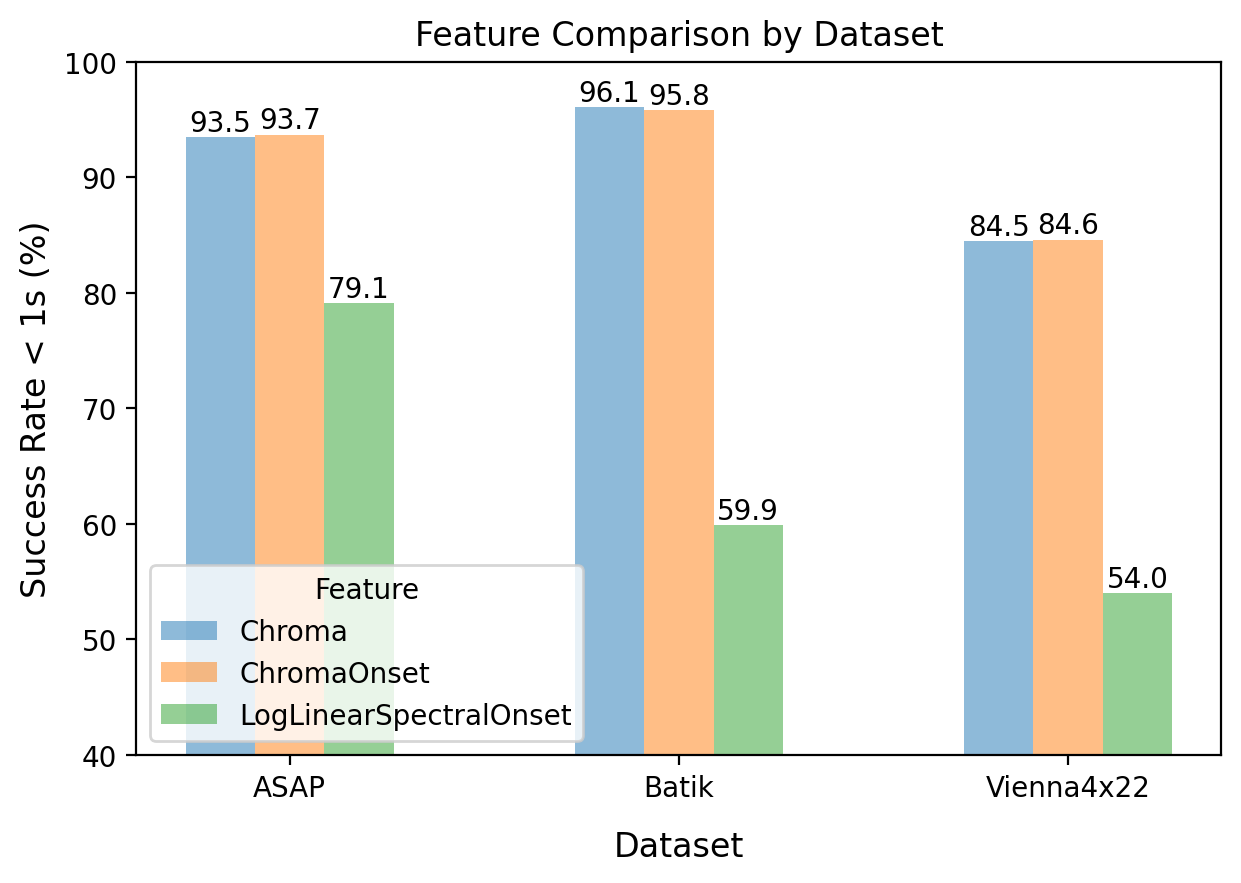

In [6]:
# Create the bar plot
import matplotlib.cm as cm

cmap = cm.get_cmap("Set1")
sm = cm.ScalarMappable(cmap=cmap)

data = {
    "Feature": ["Chroma", "LogLinearSpectralOnset", "ChromaOnset"],
    "ASAP": [93.5, 79.1, 93.7],
    "Batik": [96.1, 59.9, 95.8],
    "Vienna4x22": [84.5, 54.0, 84.6],
}
df = pd.DataFrame(data)

# Reorder the rows based on the Feature column
df = (
    df.set_index("Feature")
    .loc[["Chroma", "ChromaOnset", "LogLinearSpectralOnset"]]
    .reset_index()
)

# Transpose the DataFrame to group bars by dataset
df = df.set_index("Feature").transpose()

# Create the bar plot
fig, ax = plt.subplots(figsize=(7, 4.5))

# Set the positions and width for the bars
width = 0.13
positions = [p * (width + 0.6) for p in range(len(df))]

# Plotting each feature's bars
for i, feature in enumerate(df.columns):
    bars = ax.bar(
        [p + i * width for p in positions],
        df[feature],
        width,
        alpha=0.5,
        label=feature,
        # color=cmap(i / len(df.columns)),
    )

    # Add data values on top of the bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.01,
            round(yval, 2),
            ha="center",
            va="bottom",
        )

# Calculate the middle position of each bar group
middle_positions = [p + width * (len(df.columns) - 1) / 2 for p in positions]

# Adding the dataset names as x-ticks at the middle of each bar group
ax.set_xticks(middle_positions)
ax.set_xticklabels(df.index)

# Y-axis label
ax.set_ylabel("Success Rate < 1s (%)", fontsize=12)

# Setting the x-axis label
ax.set_xlabel("Dataset", fontsize=12, labelpad=10)
ax.set_ylim(40, 100)

# Title of the plot
ax.set_title("Feature Comparison by Dataset")

# Adding a legend and moving it outside the plot area
# ax.legend(title="Feature", bbox_to_anchor=(0.5, -0.15), loc="upper center")
ax.legend(title="Feature", loc="lower left")

# Display the plot
plt.show()

NameError: name 'df' is not defined

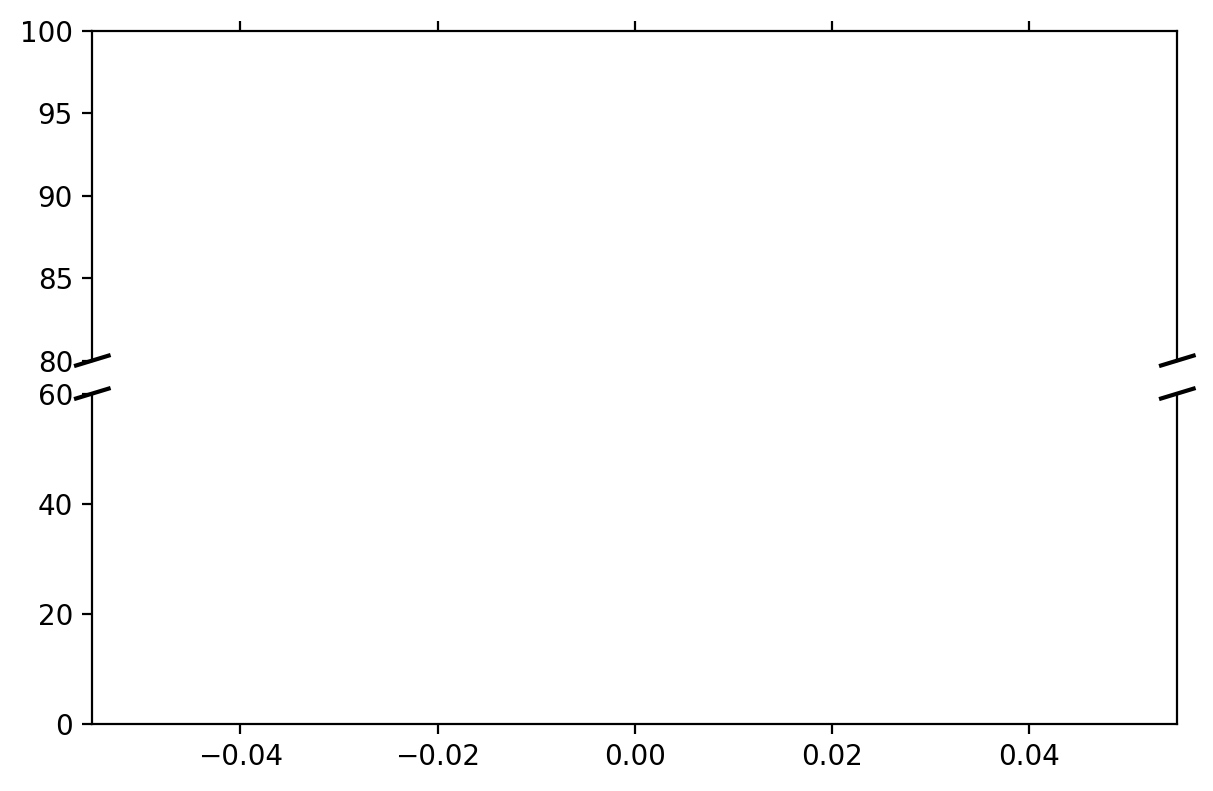

In [2]:
import matplotlib.pyplot as plt

# Create the bar plot
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 4.5))

# Adjust the space between the two subplots
fig.subplots_adjust(hspace=0.1)

# Set the y-axis limit for each subplot
ax1.set_ylim(80, 100)  # for the upper subplot
ax2.set_ylim(0, 60)  # for the lower subplot

# Hide the spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

# This function is used to create a break mark on the y-axis
def break_yaxis(ax1, ax2):
    d = .015  # how big to make the diagonal lines in axes coordinates
    # arguments to pass to plot, just so we don't keep repeating them
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

    kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

# Call the function to create a break mark on the y-axis
break_yaxis(ax1, ax2)

# Set the positions and width for the bars
width = 0.13
positions = [p * (width + 0.6) for p in range(len(df))]

# Calculate the middle position of each bar group
middle_positions = [p + width * (len(df.columns) - 1) / 2 for p in positions]

# Plotting each feature's bars
for i, feature in enumerate(df.columns):
    above_80 = df.loc[df[feature] >= 80, feature]
    below_80 = df.loc[df[feature] < 80, feature]
    pos_above_80 = [p + i * width for p in range(len(above_80))]
    pos_below_80 = [p + i * width for p in range(len(below_80))]

    bars1 = ax1.bar(
        pos_above_80,
        above_80,  # only plot the values >= 80 in the upper subplot
        width,
        alpha=0.5,
        label=feature,
        color=cmap(i / len(df.columns)),
    )
    bars2 = ax2.bar(
        pos_below_80,
        below_80,  # only plot the values < 80 in the lower subplot
        width,
        alpha=0.5,
        label=feature,
        color=cmap(i / len(df.columns)),
    )

    # Add data values on top of the bars
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.01,
            round(yval, 2),
            ha="center",
            va="bottom",
        )
    for bar in bars2:
        yval = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.01,
            round(yval, 2),
            ha="center",
            va="bottom",
        )

# Adding the dataset names as x-ticks at the middle of each bar group
ax2.set_xticks(middle_positions)
ax2.set_xticklabels(df.index)

# Y-axis label
ax1.set_ylabel("Success Rate < 1s (%)", fontsize=12)
ax2.set_ylabel("Success Rate < 1s (%)", fontsize=12)

# Setting the x-axis label
ax2.set_xlabel("Dataset", fontsize=12, labelpad=10)

# Title of the plot
ax1.set_title("Feature Comparison by Dataset (Draft)")

# Adding a legend and moving it outside the plot area
ax2.legend(title="Feature", bbox_to_anchor=(0.5, -0.15), loc="upper center")

# Display the plot
plt.show()